In [ ]:
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.neighbors import KNeighborsClassifier,NeighborhoodComponentsAnalysis,LocalOutlierFactor
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files
uploaded =files.upload()

Saving data.csv to data.csv


In [ ]:
data=pd.read_csv('data.csv')

In [ ]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
data_cleaned = data.drop(columns=['Unnamed: 32','id'])

In [ ]:
data_cleaned.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
data_cleaned['diagnosis'] = data_cleaned['diagnosis'].map({'M': 1, 'B': 0})

In [ ]:
y=data_cleaned.diagnosis
x=data_cleaned.drop(["diagnosis"],axis=1)
coulumns=x.columns.tolist()

In [ ]:
clf=LocalOutlierFactor()
out_predict=clf.fit_predict(x)
X_score=clf.negative_outlier_factor_
outlier_score=pd.DataFrame()
outlier_score["Score"]=X_score
outlier_score["Score"].head(20)

,Score
0,-1.422440
1,-1.066782
2,-0.978948
3,-1.596933
4,-1.069936
5,-1.773071
6,-1.015687
7,-1.251746
8,-1.380515
9,-1.644357


In [ ]:
threshold=-2.5
filtre=outlier_score["Score"]<threshold
outlier_index=outlier_score[filtre].index.tolist()

In [ ]:
X = data_cleaned.drop('diagnosis', axis=1)
y =  data_cleaned['diagnosis']

scaler = MinMaxScaler()
x = scaler.fit_transform(x)
X_train,X_test,Y_train,Y_test=train_test_split(x,y,random_state=42,test_size=0.3)

In [ ]:
class_counts = data_cleaned['diagnosis'].value_counts()
print(class_counts)

diagnosis
0    357
1    212
Name: count, dtype: int64


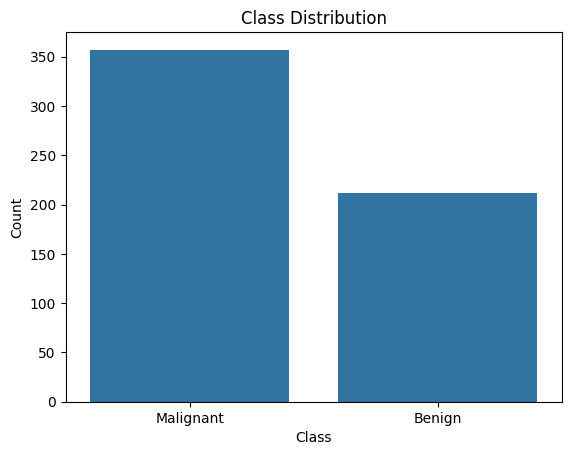

In [ ]:
# Plot the class distribution
sns.countplot(x='diagnosis', data=data_cleaned)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.show()


In [ ]:
class_proportions = data_cleaned['diagnosis'].value_counts(normalize=True)
print("Class proportions:\n", class_proportions)

Class proportions:
 diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64


In [ ]:
print(data_cleaned['diagnosis'].unique())

[1 0]


In [ ]:
from imblearn.over_sampling import SMOTE


# Initialize SMOTE
smote = SMOTE(random_state=42)
print(data_cleaned['diagnosis'].unique())
# Fit SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, Y_train)



# Initialize the classifier
clf = RandomForestClassifier(random_state=42)

# Fit the model to the resampled training set
clf.fit(X_train_smote, y_train_smote)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))

[1 0]
Accuracy: 0.9766081871345029

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       108
           1       0.95      0.98      0.97        63

    accuracy                           0.98       171
   macro avg       0.97      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



KNN

In [ ]:
knn=KNeighborsClassifier()
knn.fit(X_train_smote, y_train_smote)
Y_pred=knn.predict(X_test)
acc=accuracy_score(Y_test,Y_pred)
cm=confusion_matrix(Y_test,Y_pred)
score=knn.score(X_test,Y_test)
score1=knn.score(X_train,Y_train)
print("Score_Test ",score)
print("Score_Train ",score1)
print("Accuracy ",acc)
print("cm ",cm)

Score_Test  0.9649122807017544
Score_Train  0.9698492462311558
Accuracy  0.9649122807017544
cm  [[105   3]
 [  3  60]]


In [ ]:
def Knn_Best_Params(x_train,x_test,y_train,y_test):
    k_range=list(range(1,40))
    weight_options=["uniform","distance"]
    p_options=[1,2]
    param_grid=dict(n_neighbors=k_range,weights=weight_options,p=p_options)
    knn=KNeighborsClassifier()
    grid=GridSearchCV(knn,param_grid,cv=20,scoring="accuracy")
    grid.fit(x_train,y_train)
    print("Best Score {} with parameters {}".format(grid.best_score_,grid.best_params_))
    print()

    knn=KNeighborsClassifier(**grid.best_params_)
    knn.fit(x_train,y_train)
    y_pred_test=knn.predict(x_test)
    y_pred_train=knn.predict(x_train)
    acc_test=accuracy_score(y_test,y_pred_test)
    acc_train=accuracy_score(y_train,y_pred_train)
    print("Test Score {} Train Score {}".format(acc_test,acc_train))

    return grid
    grid=Knn_Best_Params(X_train,X_test,Y_train,Y_test)

PCA

In [ ]:
x_scaled=scaler.fit_transform(x)
pca=PCA(n_components=2)
X_reduced_pca=pca.fit_transform(x_scaled)
pca_data=pd.DataFrame(columns=["p1","p2"],data=X_reduced_pca)
pca_data["diagnosis"]=y

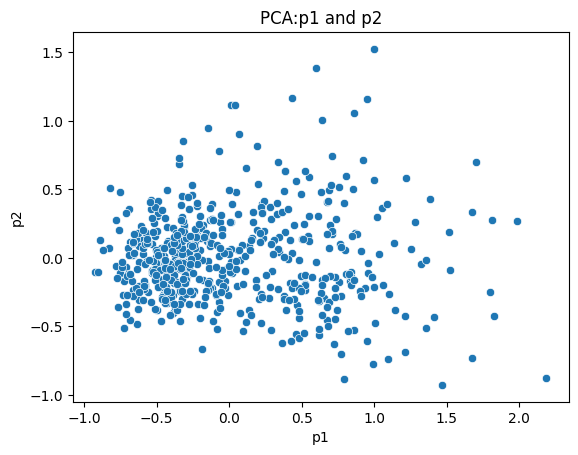

In [ ]:
sns.scatterplot(x="p1",y="p2",data=pca_data)
plt.title("PCA:p1 and p2")
plt.show()

In [ ]:
X_train_pca,X_test_pca,Y_train_pca,Y_test_pca=train_test_split(X_reduced_pca,y,random_state=42,test_size=0.3)
grid_pca=Knn_Best_Params(X_train_pca,X_test_pca,Y_train_pca,Y_test_pca)

Best Score 0.9369736842105262 with parameters {'n_neighbors': 12, 'p': 2, 'weights': 'uniform'}

Test Score 0.9415204678362573 Train Score 0.9472361809045227


**svm**

In [ ]:
# Initialize the SVM classifier
svm = SVC(random_state=42)

# Fit the model to the resampled training set
svm.fit(X_train_smote, y_train_smote)

# Make predictions on the test set
y_pred = svm.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))


Accuracy: 0.9766081871345029

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       108
           1       0.97      0.97      0.97        63

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



NCA

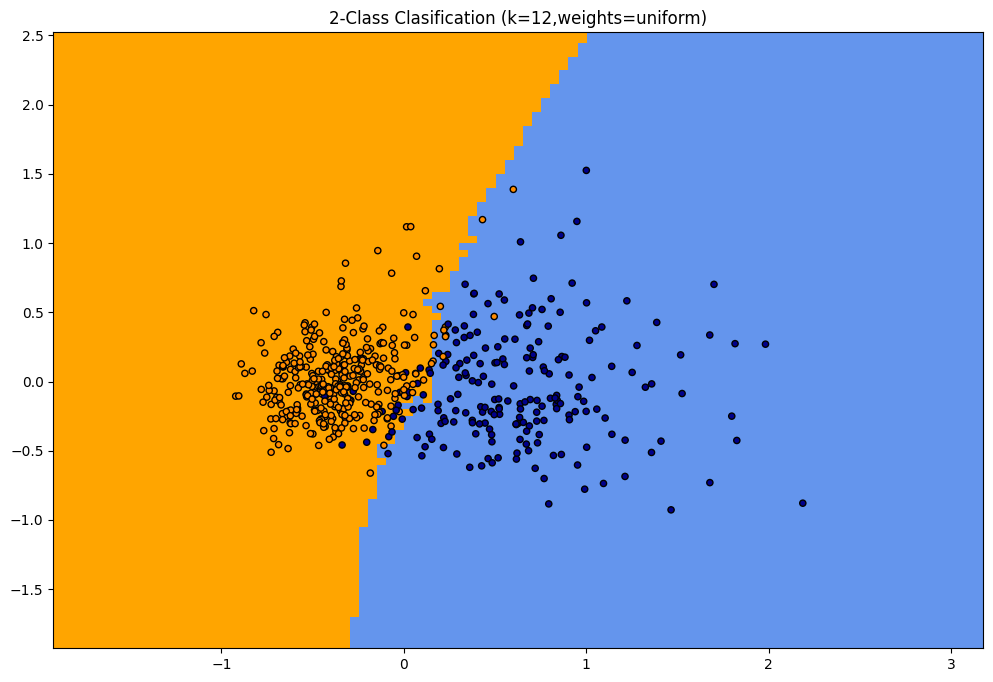

In [ ]:
cmap_light=ListedColormap(["orange","cornflowerblue"])
cmap_dark=ListedColormap(["darkorange","darkblue"])
h=.05
X=X_reduced_pca
x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
y_min,y_max=X[:,1].min()-1,X[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))
Z=grid_pca.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)
plt.figure(figsize=(12,8))
plt.pcolormesh(xx,yy,Z,cmap=cmap_light)
plt.scatter(X[:,0],X[:,1],c=y,cmap=cmap_dark,edgecolors="k",s=20)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
plt.title("%i-Class Clasification (k=%i,weights=%s)"
          %(len(np.unique(y)),grid_pca.best_estimator_.n_neighbors,grid_pca.best_estimator_.weights))
plt.show()

In [ ]:
nca=NeighborhoodComponentsAnalysis(n_components=2,random_state=42)
X_reduced_nca=nca.fit_transform(x_scaled,y)
nca_data=pd.DataFrame(columns=["p1","p2"],data=X_reduced_nca)
nca_data["target"]=y

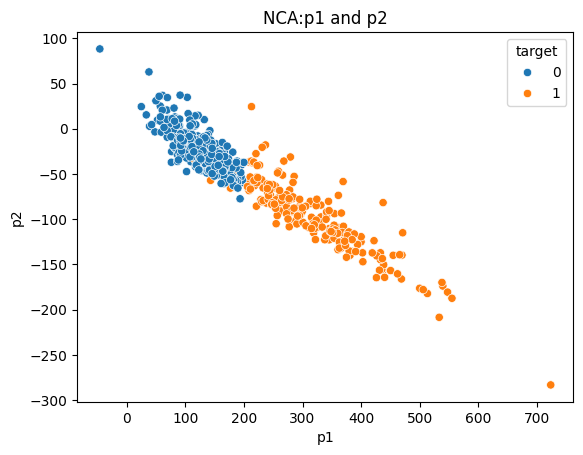

In [ ]:
sns.scatterplot(x="p1",y="p2",hue="target",data=nca_data)
plt.title("NCA:p1 and p2")
plt.show()

In [ ]:
X_train_nca,X_test_nca,Y_train_nca,Y_test_nca=train_test_split(X_reduced_nca,y,random_state=42,test_size=0.3)
grid_nca=Knn_Best_Params(X_train_nca,X_test_nca,Y_train_nca,Y_test_nca)

Best Score 0.9949999999999999 with parameters {'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}

Test Score 0.9883040935672515 Train Score 1.0


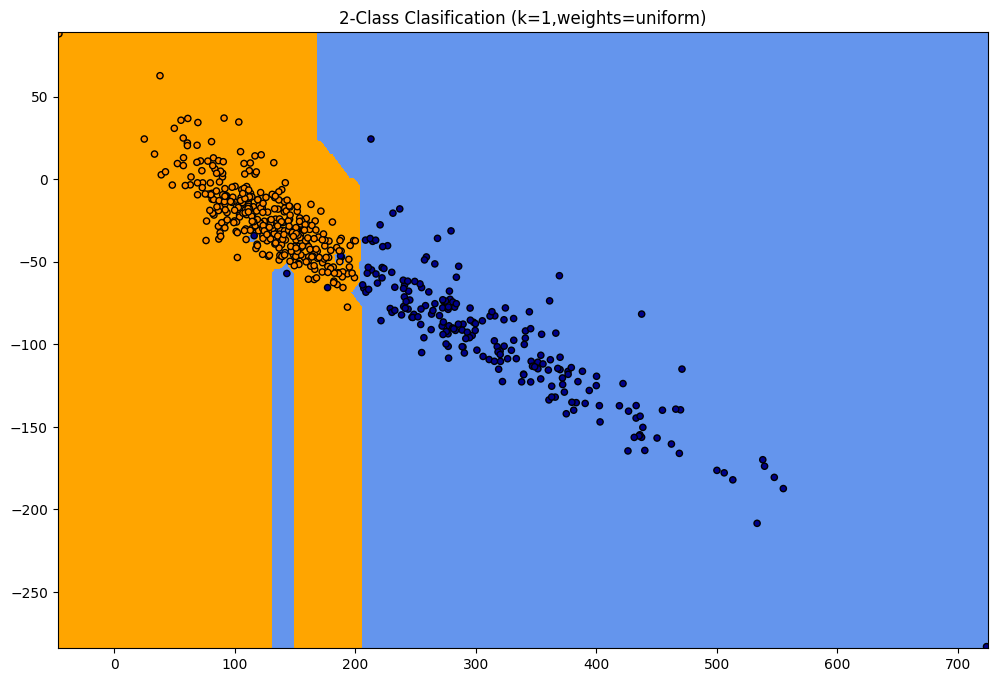

In [ ]:
cmap_light=ListedColormap(["orange","cornflowerblue"])
cmap_dark=ListedColormap(["darkorange","darkblue"])
h=.2
X=X_reduced_nca
x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
y_min,y_max=X[:,1].min()-1,X[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))
Z=grid_nca.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)
plt.figure(figsize=(12,8))
plt.pcolormesh(xx,yy,Z,cmap=cmap_light)
plt.scatter(X[:,0],X[:,1],c=y,cmap=cmap_dark,edgecolors="k",s=20)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
plt.title("%i-Class Clasification (k=%i,weights=%s)"
          %(len(np.unique(y)),grid_nca.best_estimator_.n_neighbors,grid_nca.best_estimator_.weights))
plt.show()

Mutilayer ensemble approaches

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier

# Initialize base classifiers
base_classifiers = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42)),
    ('svc', SVC(probability=True, random_state=42)),
    ('lr', LogisticRegression(random_state=42)),
    ('nb', GaussianNB())
]

# Initialize meta-classifier
meta_classifier = LogisticRegression(random_state=42)


In [ ]:
# Initialize the stacking classifier with base classifiers and meta-classifier
stacking_classifier = StackingClassifier(estimators=base_classifiers, final_estimator=meta_classifier)

# Fit the model to the resampled training set
stacking_classifier.fit(X_train_smote, y_train_smote)

# Make predictions on the test set
y_pred = stacking_classifier.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))


Accuracy: 0.9883040935672515

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       108
           1       0.98      0.98      0.98        63

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



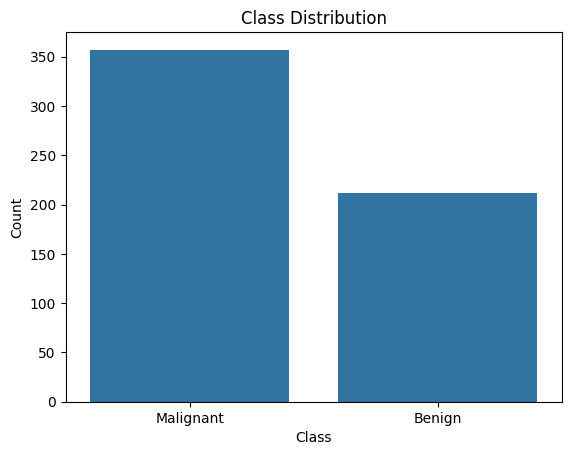

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the class distribution
sns.countplot(x='diagnosis', data=data_cleaned)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.show()


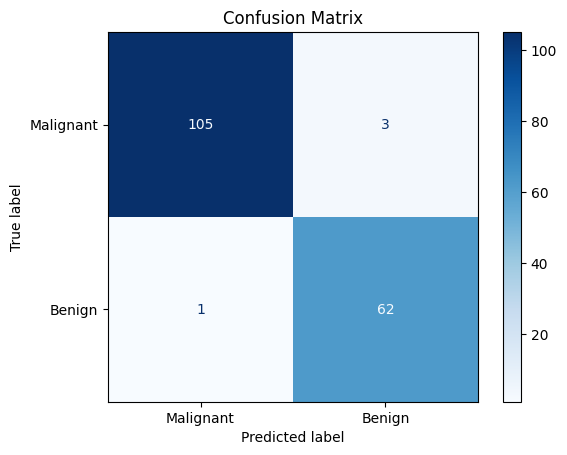

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Generate the confusion matrix
conf_matrix = confusion_matrix(Y_test, y_pred)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Malignant', 'Benign'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


Fully Connected Neural Network

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6842 - loss: 0.5880 - val_accuracy: 0.8100 - val_loss: 0.5362
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8238 - loss: 0.4319 - val_accuracy: 0.8600 - val_loss: 0.4479
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8770 - loss: 0.3244 - val_accuracy: 0.8800 - val_loss: 0.3867
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8560 - loss: 0.3168 - val_accuracy: 0.8700 - val_loss: 0.3408
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8519 - loss: 0.3526 - val_accuracy: 0.8700 - val_loss: 0.3005
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9252 - loss: 0.2189 - val_accuracy: 0.8700 - val_loss: 0.2638
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9296 - loss: 0.1991 - val_accuracy: 0.8700 - val_loss: 0.2309
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9600 - loss: 0.1696 - val_accuracy: 0.8700 - 

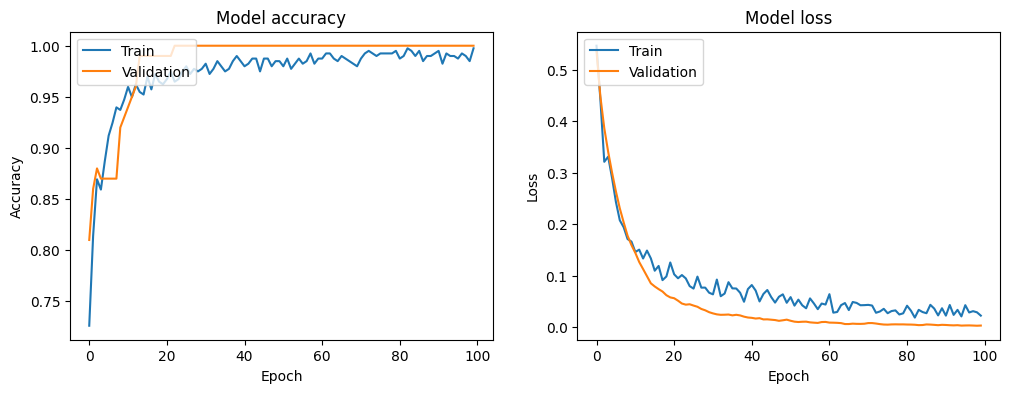

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt



# Standardize the data
scaler = StandardScaler()
X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)



# Define the neural network model
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Create the model
model = create_model(X_train_smote.shape[1])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Set early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train_smote, y_train_smote, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping])

# Make predictions on the test set
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Evaluate the model
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


confusion matrix for all the above

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier,NeighborhoodComponentsAnalysis,LocalOutlierFactor
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np





# Standardize the data
scaler = StandardScaler()
X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)

# Initialize results dictionary
results = {}

# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_smote, y_train_smote)
y_pred_lr = lr.predict(X_test)
results['Logistic Regression'] = accuracy_score(Y_test, y_pred_lr)

# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = accuracy_score(Y_test, y_pred_rf)

# Gradient Boosting Classifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_smote, y_train_smote)
y_pred_gb = gb.predict(X_test)
results['Gradient Boosting'] = accuracy_score(Y_test, y_pred_gb)

# Support Vector Machine (SVM)
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_smote, y_train_smote)
y_pred_svm = svm.predict(X_test)
results['SVM'] = accuracy_score(Y_test, y_pred_svm)

# Naive Bayes Classifier
nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)
y_pred_nb = nb.predict(X_test)
results['Naive Bayes'] = accuracy_score(Y_test, y_pred_nb)

# Neural Network (Fully Connected)
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Create and compile the model
model = create_model(X_train_smote.shape[1])
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Set early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train_smote, y_train_smote, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping])

# Make predictions on the test set
y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
results['Neural Network'] = accuracy_score(Y_test, y_pred_nn)

# K-Nearest Neighbors Classifier
knn = KNeighborsClassifier()
knn.fit(X_train_smote, y_train_smote)
y_pred_knn = knn.predict(X_test)
results['K-Nearest Neighbors'] = accuracy_score(Y_test, y_pred_knn)

# PCA for dimensionality reduction
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_smote)
X_test_pca = pca.transform(X_test)

# Train and evaluate Logistic Regression on PCA-reduced data
lr_pca = LogisticRegression(random_state=42)
lr_pca.fit(X_train_pca, y_train_smote)
y_pred_lr_pca = lr_pca.predict(X_test_pca)
results['Logistic Regression (PCA)'] = accuracy_score(Y_test, y_pred_lr_pca)


# Print the results
print(results_df)

# Plot the accuracy of all algorithms
plt.figure(figsize=(12, 8))
sns.barplot(x='Algorithm', y='Accuracy', data=results_df, palette='viridis')
plt.title('Accuracy of Different Algorithms After SMOTE')
plt.xlabel('Algorithm')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.show()

# Optional: Print confusion matrices for all algorithms
def plot_confusion_matrix(y_true, y_pred, title):
    conf_matrix = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Malignant', 'Benign'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(Y_test, y_pred_lr, 'Confusion Matrix for Logistic Regression')
plot_confusion_matrix(Y_test, y_pred_rf, 'Confusion Matrix for Random Forest')
plot_confusion_matrix(Y_test, y_pred_gb, 'Confusion Matrix for Gradient Boosting')
plot_confusion_matrix(Y_test, y_pred_svm, 'Confusion Matrix for SVM')
plot_confusion_matrix(Y_test, y_pred_nb, 'Confusion Matrix for Naive Bayes')
plot_confusion_matrix(Y_test, y_pred_nn, 'Confusion Matrix for Neural Network')
plot_confusion_matrix(Y_test, y_pred_knn, 'Confusion Matrix for K-Nearest Neighbors')
plot_confusion_matrix(Y_test, y_pred_lr_pca, 'Confusion Matrix for Logistic Regression (PCA)')




Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6070 - loss: 0.6751 - val_accuracy: 0.8500 - val_loss: 0.4893
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7985 - loss: 0.4457 - val_accuracy: 0.8900 - val_loss: 0.4103
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8601 - loss: 0.4082 - val_accuracy: 0.8900 - val_loss: 0.3540
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9078 - loss: 0.2791 - val_accuracy: 0.8900 - val_loss: 0.3240
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9049 - loss: 0.3047 - val_accuracy: 0.8900 - val_loss: 0.2915
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9140 - loss: 0.2266 - val_accuracy: 0.8900 - val_loss: 0.2620
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9369 - loss: 0.1824 - val_accuracy: 0.8900 - val_loss: 0.2393
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9401 - loss: 0.2201 - val_accuracy: 0.9000 

NameError: name 'results_df' is not defined

In [ ]:
input_data = np.array(17.99, 10.38, 122.8, 1001, 0.1184, 0.27)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)
prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 0):
  print('The Breast cancer is Malignant')

else:
  print('The Breast Cancer is Benign')

